#### Build a Simple Agent2Agent With LangGraph

In [217]:
# Import Packages
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage # AnyMessage can be (AIMessage, HumanMessage, UserMessage, ...)
from typing_extensions import TypedDict, Literal # type that we can use it in State
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from pprint import pprint

In [218]:
# Define State For Our Graph - Here We Define Historic
class ClientState(TypedDict):
    messages: list[AnyMessage]
    counter: int

In [219]:
# Define Node - Agentic Function - This Function
def node(state: ClientState):
    messages = state["messages"]
    print("Messages That We Have in States Are: ", state)
    new_messages = [AIMessage("Hello !")]
    return {"messages": messages + new_messages, "counter": state["counter"] + 1}

In [220]:
# Create Graph
workflow = StateGraph(ClientState)
workflow.add_node("Extracter_Agent", node)
workflow.add_edge(START, "Extracter_Agent")
workflow.add_edge("Extracter_Agent", END)

In [221]:
# compile take also (memory, wait for human validation, ...)
graph = workflow.compile()

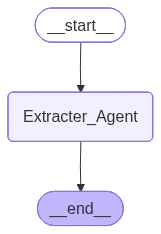

In [222]:
# Display Graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [223]:
# Execute Graph
initial_state = {"messages": [HumanMessage("Hi")], "counter": 0}
result = graph.invoke(initial_state)
pprint(result)

Messages That We Have in States Are:  {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={})], 'counter': 0}
{'counter': 1,
 'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}),
              AIMessage(content='Hello !', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


### Simple Agent for Anaylse documents

In [224]:
# Define state of agent
class EmployeeState(TypedDict):
    name: str
    age: int
    salary: float
    decisions: Literal["standard_hr", "forced_hr"]
    result: str

In [225]:
# Verfication Node
def analyze_employee(state: EmployeeState) -> EmployeeState:
    age = state["age"]
    salary = state["salary"]

    if (age <= 30 and salary <= 40000):
        state["decisions"] = "standard_hr"
    else:
        state["decisions"] = "forced_hr"
    return state

In [226]:
# Path 1 - Age <= 30 and Salary <= 40000
def standard_hr_process(state: EmployeeState):
    state["result"] = f"""Demand to {state["name"]} to send RH Standard the Document"""
    return state

In [227]:
# Path 2
def forced_hr_process(state: EmployeeState):
    state["result"] = f"""Demand to {state["name"]} to send RH Forced the Document"""
    return state

In [228]:
# Conditionnel Routing Function
def router(state: EmployeeState):
    return state['decisions']

In [229]:
# Create Graph With EmployeeState
hr_workflow = StateGraph(EmployeeState)

# Add Node
hr_workflow.add_node("Anaylze_Employee", analyze_employee)
hr_workflow.add_node("Standard_RH_Process", standard_hr_process)
hr_workflow.add_node("Forced_RH_Process", forced_hr_process)

# Create Edge
hr_workflow.add_edge(START, "Anaylze_Employee")
hr_workflow.add_conditional_edges("Anaylze_Employee", 
    router,
    {
        "standard_hr": "Standard_RH_Process",
        "forced_hr": "Forced_RH_Process"
    }
)

hr_workflow.add_edge("Standard_RH_Process", END)
hr_workflow.add_edge("Forced_RH_Process", END)

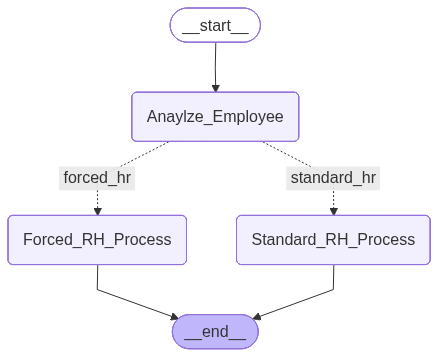

In [230]:
# Display The Graph
graph = hr_workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [231]:
# Execute Graph
initial_state = {"name": "abdellah", "age": 20, "salary": 90000}
result = graph.invoke(initial_state)
pprint(result)

{'age': 20,
 'decisions': 'forced_hr',
 'name': 'abdellah',
 'result': 'Demand to abdellah to send RH Forced the Document',
 'salary': 90000}


#### Start Graph With Loop

In [232]:
# Create State
class AdminastrationState(TypedDict):
    name: str
    remaining_documents: int
    reminders: int
    status: Literal["incomplet", "complete", "validated"]

In [233]:
# Verfication Node
def verfication_employee_file(state: AdminastrationState):
    if (state["remaining_documents"]  > 0):
        state["status"] = "incomplet"
    elif (state["remaining_documents"] == 0):
        state["status"] = "complete"
    
    print("*" * 50)
    print(f"Checking {state["name"]}'s file, current status: {state["status"]}")
    return state

In [ ]:
# Define Router on File Verfication Agent
def router(state: AdminastrationState):
    if state["status"] == "incomplet": 
        return "notify"
    else:
        return "validate"

In [235]:
# Notify Employee Node or Agent
def notify_employee(state: AdminastrationState):
    state["reminders"] += 1
    if (state["remaining_documents"] > 0):
        state["remaining_documents"] -= 1
    print("-" * 50)
    print(f"Notification {state["reminders"]} of employee {state["name"]}")
    print(f"Remaining Documents {state["remaining_documents"]}")
    return state

In [236]:
# File Validation Agent
def file_validation(state: AdminastrationState):
    state["status"] = "validated"
    print("*" * 50)
    print(f"DONE: Validation {state["name"]} With INFO: remaining_documents = {state["remaining_documents"]} AND reminders = {state["reminders"]}")
    return state

In [244]:
# Create graph
adminstration_workflow = StateGraph(AdminastrationState)

# Create Node
adminstration_workflow.add_node("verfication_employee_file", verfication_employee_file)
adminstration_workflow.add_node("notify_employee", notify_employee)
adminstration_workflow.add_node("file_validation", file_validation)

# Create Edge
# adminstration_workflow.add_edge(START, "verfication_employee_file")
adminstration_workflow.set_entry_point("verfication_employee_file")
adminstration_workflow.add_conditional_edges("verfication_employee_file", 
    router, {
        "notify": "notify_employee",
        "validate": "file_validation",
    })
adminstration_workflow.add_edge("notify_employee", "verfication_employee_file")
adminstration_workflow.add_edge("file_validation", END)

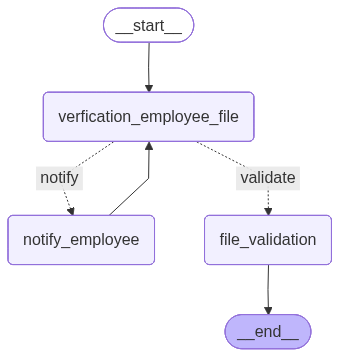

In [ ]:
# Execute The Graph
graph = adminstration_workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [248]:
# Test MultiAgent
initial_state = {"name": "Abdellah Karani", "remaining_documents": 3, "reminders": 0}
result = graph.invoke(initial_state)
print(result)

**************************************************
Checking Abdellah Karani's file, current status: incomplet
--------------------------------------------------
Notification 1 of employee Abdellah Karani
Remaining Documents 2
**************************************************
Checking Abdellah Karani's file, current status: incomplet
--------------------------------------------------
Notification 2 of employee Abdellah Karani
Remaining Documents 1
**************************************************
Checking Abdellah Karani's file, current status: incomplet
--------------------------------------------------
Notification 3 of employee Abdellah Karani
Remaining Documents 0
**************************************************
Checking Abdellah Karani's file, current status: complete
**************************************************
DONE: Validation Abdellah Karani With INFO: remaining_documents = 0 AND reminders = 3
{'name': 'Abdellah Karani', 'remaining_documents': 0, 'reminders': 3, 'statu